# Student 3 + Naive RAG

Этот notebook работает именно с таким JSON, который тебе скинул Student 2.

JSON структура:

```text
strategies
 ├── fixed_size_200
 ├── fixed_size_500
 ├── recursive
 ├── sentence_4
 └── semantic
```

Внутри каждой стратегии уже есть готовые chunks.

Твоя задача:

```text
1. загрузить JSON от Student 2
2. взять chunks из каждой стратегии
3. проверить chunks через LLM-as-a-Judge
4. выбрать лучшую стратегию по context independence
5. построить обычный Naive RAG на лучших chunks
```

## 1. Install

In [ ]:
# !pip install -U langchain langchain-openai langchain-chroma python-dotenv pandas chromadb

## 2. Imports

In [1]:
import os
import json
import shutil
import pandas as pd

from dotenv import load_dotenv

from langchain_core.documents import Document
from langchain_openai import ChatOpenAI, OpenAIEmbeddings
from langchain_chroma import Chroma
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.output_parsers import StrOutputParser

## 3. API key

Вариант простой: создай `.env` рядом с notebook:

```env
OPENAI_API_KEY=sk-...
```

Или временно вставь ключ прямо в `os.environ`.

In [2]:
load_dotenv("/Users/nurdauletaldibek/Desktop/Nfac/.env")
OPENAI_API_KEY = os.getenv("OPENAI_API_KEY")

if not OPENAI_API_KEY:
    raise ValueError("OPENAI_API_KEY не найден")

embedding = OpenAIEmbeddings(
    model="text-embedding-3-large",
    dimensions=3072,
    api_key=OPENAI_API_KEY,
)

llm = ChatOpenAI(
    model="gpt-4o-mini",
    temperature=0.0,
    api_key=OPENAI_API_KEY,
)

print("LLM и embeddings готовы")


LLM и embeddings готовы


## 4. Load JSON от Student 2

Сохрани JSON, который тебе скинули, в файл:

```text
data/step2_chunks.json
```

In [5]:
json_path = "/Users/nurdauletaldibek/Desktop/nfac_project_seminar/step2-chunks.json"

with open(json_path, "r", encoding="utf-8") as f:
    data = json.load(f)

print(data.keys())
print(data["strategies"].keys())

dict_keys(['_description', 'source', 'config', 'strategies'])
dict_keys(['fixed_size_200', 'fixed_size_500', 'recursive', 'sentence_4', 'semantic'])


## 5. Достаём chunks из JSON

Каждый chunk выглядит так:

```json
{
  "id": 0,
  "text": "...",
  "char_count": 314,
  "num_sentences": 3
}
```

In [6]:
def get_chunks_from_strategy(data, strategy_name):
    chunk_items = data["strategies"][strategy_name]["chunks"]

    chunks = []

    for item in chunk_items:
        chunks.append({
            "strategy": strategy_name,
            "chunk_id": item["id"],
            "text": item["text"],
            "char_count": item.get("char_count"),
            "num_sentences": item.get("num_sentences"),
        })

    return chunks


recursive_chunks = get_chunks_from_strategy(data, "recursive")

print("Recursive chunks:", len(recursive_chunks))
print(recursive_chunks[0]["text"][:500])

Recursive chunks: 16
МАЙ
13.05.2024
Крупнейший телеком-оператор страны и международный лидер в сфере облачных и edge-услуг Gcore договорились совместно развивать в Казахстане стриминговые и мультимедийные технологии и сервисы. Соответствующий меморандум подписан в Астане при поддержке национальной компании «KAZAKH INVEST».
20.05.2024


# Student 3: Context Independence Judge

Проверяем:

```text
понятен ли chunk сам по себе без предыдущего и следующего chunk?
```

## 6. Judge prompt

In [7]:
judge_prompt = ChatPromptTemplate.from_template("""
Ты проверяешь chunk для RAG.

Вопрос:
Можно ли понять этот chunk сам по себе,
без предыдущего и следующего chunk?

Оцени от 1 до 5:
5 = полностью понятен сам по себе
4 = почти понятен
3 = частично понятен, но нужен соседний контекст
2 = плохо понятен
1 = непонятен

Обрати внимание:
- начинается ли chunk с середины мысли
- заканчивается ли chunk нормально
- понятны ли местоимения типа "это", "он", "они", "данный"
- есть ли законченная идея

Chunk:
{chunk}

Верни только JSON:
{{
  "score": 1,
  "reason": "кратко почему такая оценка"
}}
""")

judge_chain = judge_prompt | llm | StrOutputParser()

## 7. JSON parser

In [8]:
def parse_json(raw):
    try:
        return json.loads(raw)
    except:
        start = raw.find("{")
        end = raw.rfind("}") + 1

        if start != -1 and end != 0:
            try:
                return json.loads(raw[start:end])
            except:
                pass

        return {
            "score": None,
            "reason": raw
        }

## 8. Judge one chunk

In [9]:
def judge_chunk(chunk_text):
    raw = judge_chain.invoke({
        "chunk": chunk_text
    })

    return parse_json(raw)

## 9. Test на одном chunk

In [10]:
test_chunk = recursive_chunks[0]["text"]

print(test_chunk)
print("\n--- Judge ---")

judge_chunk(test_chunk)

МАЙ
13.05.2024
Крупнейший телеком-оператор страны и международный лидер в сфере облачных и edge-услуг Gcore договорились совместно развивать в Казахстане стриминговые и мультимедийные технологии и сервисы. Соответствующий меморандум подписан в Астане при поддержке национальной компании «KAZAKH INVEST».
20.05.2024

--- Judge ---


{'score': 3,
 'reason': 'Частично понятен, но нужен соседний контекст. Начало и конец предложения не дают полной картины, и неясно, о каких именно технологиях и сервисах идет речь.'}

## 10. Проверяем одну стратегию

Например сначала проверим только `recursive`, потому что Student 2 уже рекомендовал её по semantic coherence.

In [ ]:
def evaluate_strategy(data, strategy_name):
    chunks = get_chunks_from_strategy(data, strategy_name)
    rows = []

    for i, item in enumerate(chunks):
        print(f"{strategy_name}: chunk {i + 1}/{len(chunks)}")

        judge = judge_chunk(item["text"])

        rows.append({
            "strategy": strategy_name,
            "chunk_id": item["chunk_id"],
            "text": item["text"],
            "char_count": item["char_count"],
            "num_sentences": item["num_sentences"],
            "score": judge.get("score"),
            "reason": judge.get("reason"),
        })

    return pd.DataFrame(rows)


recursive_results = evaluate_strategy(data, "recursive")
recursive_results.head()

## 11. Summary для recursive

In [ ]:
recursive_results["score"].mean()

## 12. Проверяем все стратегии

Если хочешь дешевле — можешь не запускать все, а оставить только `recursive`.

Но для полноценного Student 3 лучше проверить все стратегии.

In [13]:
all_results = []

for strategy_name in data["strategies"].keys():
    result_df = evaluate_strategy(data, strategy_name)
    all_results.append(result_df)

context_independence_results = pd.concat(all_results, ignore_index=True)
context_independence_results.head()

fixed_size_200: chunk 1/29
fixed_size_200: chunk 2/29
fixed_size_200: chunk 3/29
fixed_size_200: chunk 4/29
fixed_size_200: chunk 5/29
fixed_size_200: chunk 6/29
fixed_size_200: chunk 7/29
fixed_size_200: chunk 8/29
fixed_size_200: chunk 9/29
fixed_size_200: chunk 10/29
fixed_size_200: chunk 11/29
fixed_size_200: chunk 12/29
fixed_size_200: chunk 13/29
fixed_size_200: chunk 14/29
fixed_size_200: chunk 15/29
fixed_size_200: chunk 16/29
fixed_size_200: chunk 17/29
fixed_size_200: chunk 18/29
fixed_size_200: chunk 19/29
fixed_size_200: chunk 20/29
fixed_size_200: chunk 21/29
fixed_size_200: chunk 22/29
fixed_size_200: chunk 23/29
fixed_size_200: chunk 24/29
fixed_size_200: chunk 25/29
fixed_size_200: chunk 26/29
fixed_size_200: chunk 27/29
fixed_size_200: chunk 28/29
fixed_size_200: chunk 29/29
fixed_size_500: chunk 1/12
fixed_size_500: chunk 2/12
fixed_size_500: chunk 3/12
fixed_size_500: chunk 4/12
fixed_size_500: chunk 5/12
fixed_size_500: chunk 6/12
fixed_size_500: chunk 7/12
fixed_si

,strategy,chunk_id,text,char_count,num_sentences,score,reason
0,fixed_size_200,0,МАЙ\n13.05.2024\nКрупнейший телеком-оператор с...,200,1,2,"Chunk плохо понятен, так как он обрывается на ..."
1,fixed_size_200,1,висы. Соответствующий меморандум подписан в Ас...,200,3,2,"Chunk плохо понятен, так как начинается с сере..."
2,fixed_size_200,2,должаются работы по выбору компании-подрядчика...,200,2,2,Chunk начинается с середины мысли и не содержи...
3,fixed_size_200,3,Баку консультантом проекта - компанией Ploneer...,199,3,1,"Chunk не содержит законченной мысли, начинаетс..."
4,fixed_size_200,4,егированную акци итогам 2023 года составит 2 0...,200,3,2,"Chunk плохо понятен, так как начинается с сере..."


## 13. Summary по стратегиям

In [16]:
summary = (
    context_independence_results
    .groupby("strategy", as_index=False)
    .agg(
        avg_independence_score=("score", "mean"),
        num_chunks=("chunk_id", "count"),
        avg_chars=("char_count", "mean"),
        avg_sentences=("num_sentences", "mean"),
    )
    .sort_values("avg_independence_score", ascending=False)
)

summary

,strategy,avg_independence_score,num_chunks,avg_chars,avg_sentences
2,recursive,3.250000,16,362.187500,3.750000
4,sentence_4,2.916667,12,468.666667,3.916667
3,semantic,2.750000,4,1408.000000,11.750000
1,fixed_size_500,2.083333,12,469.416667,4.833333
0,fixed_size_200,1.758621,29,194.275862,2.551724


## 14. Save results

In [17]:
context_independence_results.to_csv(
    "student3_context_independence_results.csv",
    index=False,
    encoding="utf-8"
)

summary.to_csv(
    "student3_context_independence_summary.csv",
    index=False,
    encoding="utf-8"
)

print("saved")

saved


## 14.1 Сравнение всех стратегий

Тут видно:

```text
какая стратегия сколько баллов получила
какая стратегия лучше
```

Мы сравниваем по `avg_independence_score`.

Чем выше score, тем лучше chunks понятны сами по себе.

In [18]:
comparison = summary.copy()

comparison["rank"] = comparison["avg_independence_score"].rank(
    ascending=False,
    method="dense"
).astype(int)

comparison = comparison.sort_values("rank")

comparison

,strategy,avg_independence_score,num_chunks,avg_chars,avg_sentences,rank
2,recursive,3.250000,16,362.187500,3.750000,1
4,sentence_4,2.916667,12,468.666667,3.916667,2
3,semantic,2.750000,4,1408.000000,11.750000,3
1,fixed_size_500,2.083333,12,469.416667,4.833333,4
0,fixed_size_200,1.758621,29,194.275862,2.551724,5


## 14.2 Красивый вывод сравнения

## 14.3 Bar plot сравнения

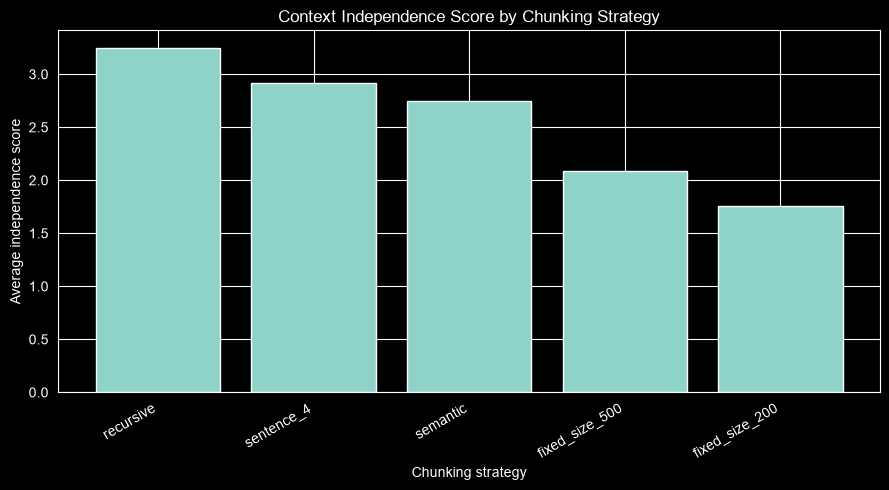

In [20]:
import matplotlib.pyplot as plt

plt.figure(figsize=(9, 5))

plt.bar(
    comparison["strategy"],
    comparison["avg_independence_score"]
)

plt.title("Context Independence Score by Chunking Strategy")
plt.xlabel("Chunking strategy")
plt.ylabel("Average independence score")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

## 14.4 Финальное решение

Здесь notebook сам пишет, какая стратегия лучшая и почему.

In [21]:
best_strategy = comparison.iloc[0]["strategy"]
best_score = comparison.iloc[0]["avg_independence_score"]

final_decision = f"""
Best chunking strategy by Context Independence: {best_strategy}

Score: {best_score:.2f}

Why this strategy is better:
It received the highest average score from LLM-as-a-Judge.
This means its chunks are more understandable without previous or next chunks.
So these chunks are better for Naive RAG.
"""

print(final_decision)


Best chunking strategy by Context Independence: recursive

Score: 3.25

Why this strategy is better:
It received the highest average score from LLM-as-a-Judge.
This means its chunks are more understandable without previous or next chunks.
So these chunks are better for Naive RAG.



## 15. Выбираем лучшую стратегию

In [22]:
best_strategy = summary.iloc[0]["strategy"]

print("Best strategy by Context Independence:", best_strategy)

Best strategy by Context Independence: recursive


# Naive RAG

Теперь берём chunks лучшей стратегии и строим обычный Naive RAG.

```text
best strategy chunks
↓
Document
↓
embeddings
↓
ChromaDB
↓
retriever
↓
LLM answer
```

## 16. Convert best chunks to Documents

In [23]:
best_chunks = get_chunks_from_strategy(data, best_strategy)

documents = [
    Document(
        page_content=item["text"],
        metadata={
            "strategy": item["strategy"],
            "chunk_id": item["chunk_id"],
            "char_count": item["char_count"],
            "num_sentences": item["num_sentences"],
        }
    )
    for item in best_chunks
]

print("Documents:", len(documents))
print(documents[0])

Documents: 16
page_content='МАЙ
13.05.2024
Крупнейший телеком-оператор страны и международный лидер в сфере облачных и edge-услуг Gcore договорились совместно развивать в Казахстане стриминговые и мультимедийные технологии и сервисы. Соответствующий меморандум подписан в Астане при поддержке национальной компании «KAZAKH INVEST».
20.05.2024' metadata={'strategy': 'recursive', 'chunk_id': 0, 'char_count': 314, 'num_sentences': 3}


## 17. Create ChromaDB

In [24]:
db_path = "./chroma_student3"

if os.path.exists(db_path):
    shutil.rmtree(db_path)

vectorstore = Chroma.from_documents(
    documents=documents,
    embedding=embedding,
    collection_name="student3_naive_rag",
    persist_directory=db_path,
)

retriever = vectorstore.as_retriever(
    search_kwargs={"k": 5}
)

print("ChromaDB created")

ChromaDB created


## 18. RAG prompt

In [25]:
rag_prompt = ChatPromptTemplate.from_template("""
Ты RAG ассистент.

Отвечай только на основе контекста.
Если ответа нет в контексте, скажи:
"Не могу ответить на основе найденного контекста."

Контекст:
{context}

Вопрос:
{question}

Ответ:
""")

rag_chain = rag_prompt | llm | StrOutputParser()

## 19. RAG function

In [26]:
def format_docs(docs):
    return "\n\n---\n\n".join(
        f"strategy={doc.metadata.get('strategy')} | chunk_id={doc.metadata.get('chunk_id')}\n{doc.page_content}"
        for doc in docs
    )


def naive_rag(question):
    docs = retriever.invoke(question)
    context = format_docs(docs)

    answer = rag_chain.invoke({
        "context": context,
        "question": question,
    })

    return answer, docs

## 20. Test Naive RAG

In [ ]:
question = "О чем говорится в документе?"

answer, docs = naive_rag(question)

print("Answer:")
print(answer)

print("\nRetrieved chunks:")
for doc in docs:
    print("=" * 80)
    print(doc.metadata)
    print(doc.page_content[:700])

## 21. Несколько вопросов

In [29]:
questions = [

    "Какие исторические события Казахтелекома указаны в тексте?",
]

rag_rows = []

for q in questions:
    answer, docs = naive_rag(q)

    rag_rows.append({
        "question": q,
        "answer": answer,
        "retrieved_chunk_ids": [doc.metadata.get("chunk_id") for doc in docs],
        "strategy": best_strategy,
    })

rag_results = pd.DataFrame(rag_rows)
rag_results

,question,answer,retrieved_chunk_ids,strategy
0,Какие исторические события Казахтелекома указа...,1. 1995 - Строительство казахстанского участка...,"[12, 13, 14, 11, 3]",recursive
